Dataset loaded successfully!
Shape: 4000 rows and 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


--- Missing Values ---
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

--- Duplicates ---
Found 0 duplicate rows.

Data cleaning complete. Remaining missing values: 0

--- Seasonal Performance Summary ---


,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,,
Kharif,5.63,46.31,531804.41,710719.06,178914.65
Rabi,5.04,41.49,513836.58,601526.05,87689.47
Zaid,4.64,38.89,543976.73,519171.90,-24804.82


/tmp/ipykernel_3284/3659717548.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Season", palette="deep")


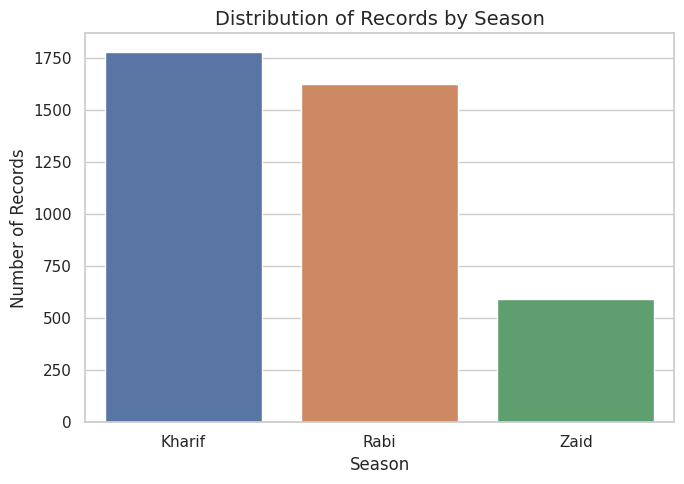

/tmp/ipykernel_3284/3659717548.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="viridis")


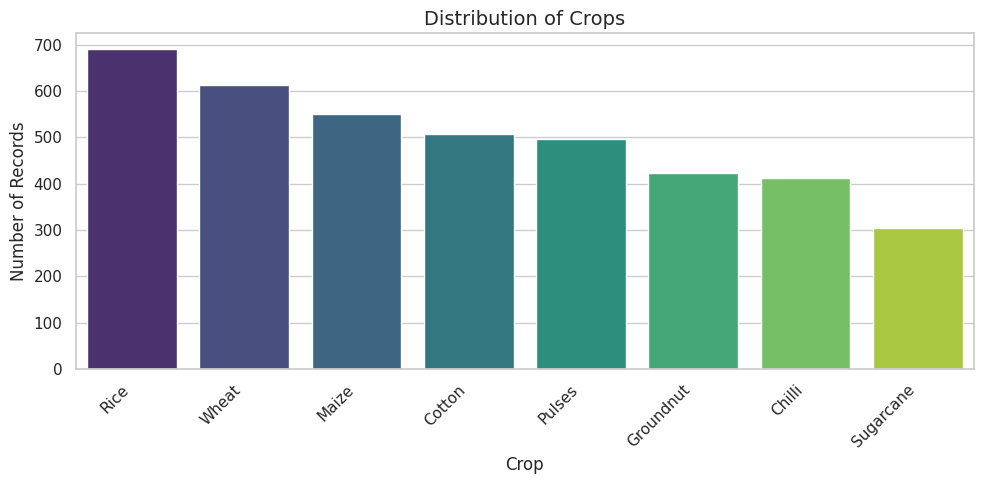

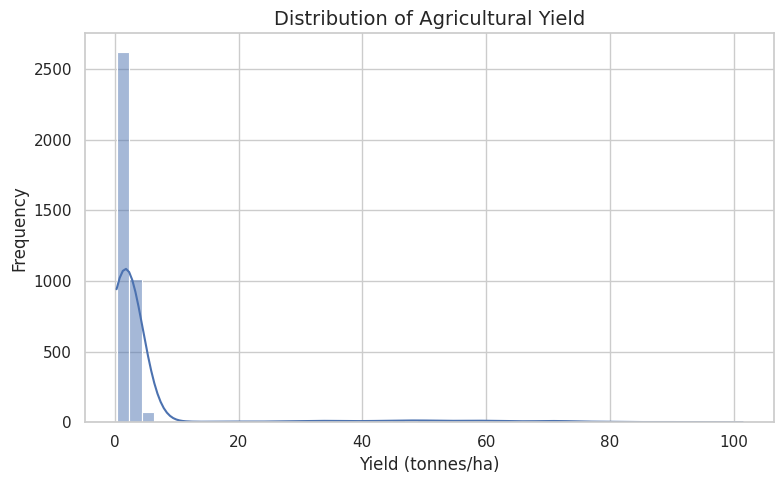

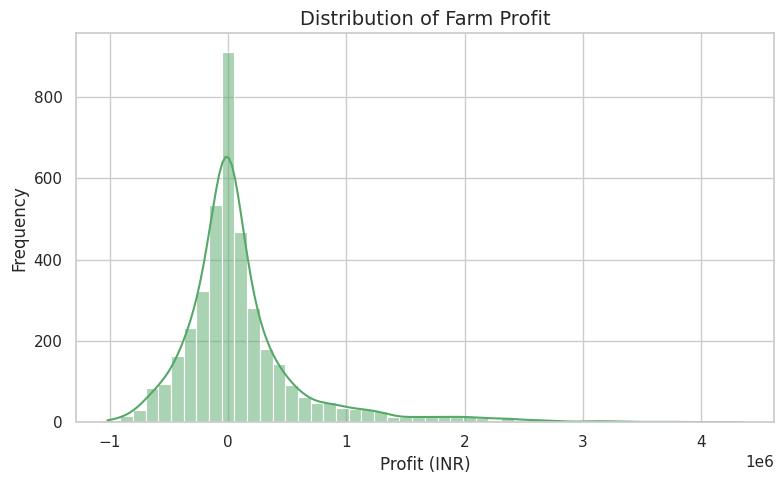

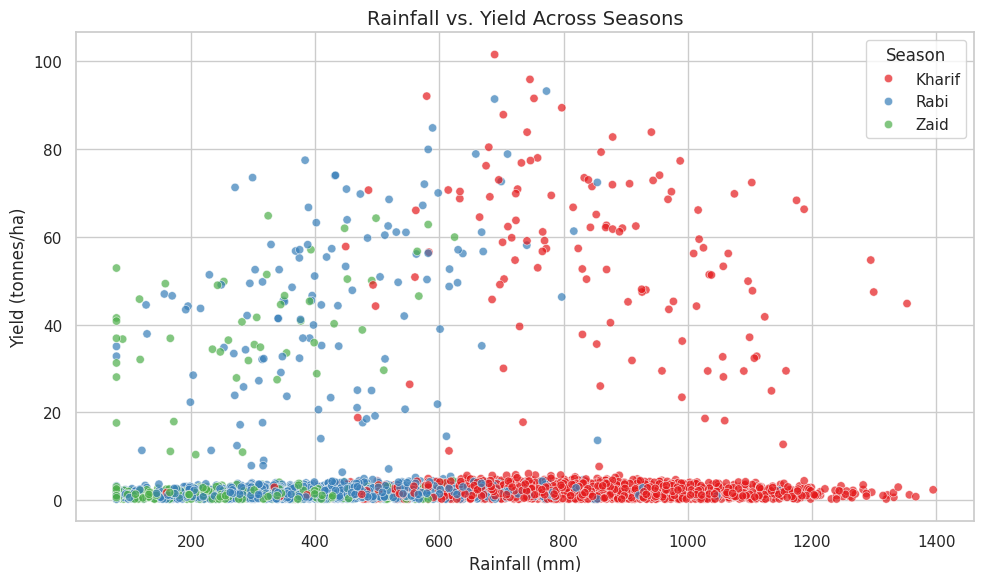

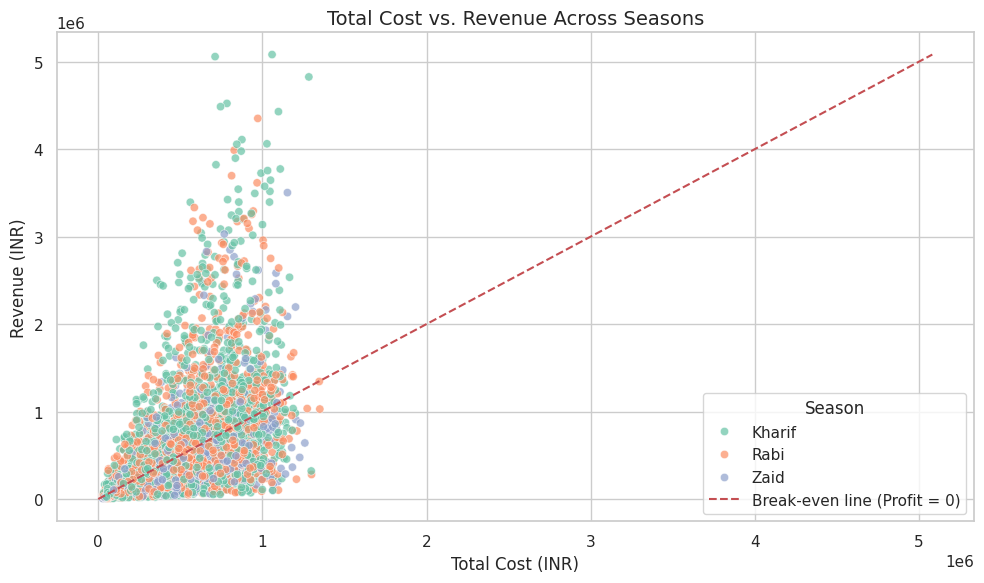

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
file_name = 'seasonal_agriculture_performance_dataset (2).csv'
try:
    df = pd.read_csv(file_name)
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found. Please ensure you have uploaded it to the Colab files panel.")

# Display the first 5 rows
display(df.head())

# Check for missing values and duplicates
print("--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0])

duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicates ---\nFound {duplicate_count} duplicate rows.")

# Clean the data
df = df.drop_duplicates().reset_index(drop=True)

# Fill numerical missing values with the median
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nData cleaning complete. Remaining missing values:", df.isnull().sum().sum())

# Display a statistical summary grouped by Season
print("\n--- Seasonal Performance Summary ---")
season_summary = df.groupby("Season")[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].mean()
display(season_summary.round(2))
# 1. Season Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season", palette="deep")
plt.title("Distribution of Records by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.tight_layout()
plt.show()

# 2. Crop Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops", fontsize=14)
plt.xlabel("Crop", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.tight_layout()
plt.show()

# 3. Yield Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True, bins=50, color="#4C72B0")
plt.title("Distribution of Agricultural Yield", fontsize=14)
plt.xlabel("Yield (tonnes/ha)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

# 4. Profit Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True, bins=50, color="#55A868")
plt.title("Distribution of Farm Profit", fontsize=14)
plt.xlabel("Profit (INR)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

# 1. Environmental Impact: Rainfall vs Yield across Seasons
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.7, palette="Set1")
plt.title("Rainfall vs. Yield Across Seasons", fontsize=14)
plt.xlabel("Rainfall (mm)", fontsize=12)
plt.ylabel("Yield (tonnes/ha)", fontsize=12)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

# 2. Economic Impact: Total Cost vs Revenue across Seasons
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Total_Cost_INR", y="Revenue_INR", hue="Season", alpha=0.7, palette="Set2")

# Add a Break-Even Line (where Cost = Revenue)
max_val = max(df["Total_Cost_INR"].max(), df["Revenue_INR"].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Break-even line (Profit = 0)')

plt.title("Total Cost vs. Revenue Across Seasons", fontsize=14)
plt.xlabel("Total Cost (INR)", fontsize=12)
plt.ylabel("Revenue (INR)", fontsize=12)
plt.legend(title="Season")
plt.tight_layout()
plt.show()